**Python implementation of Lorentz Systems given in WyNDA paper**


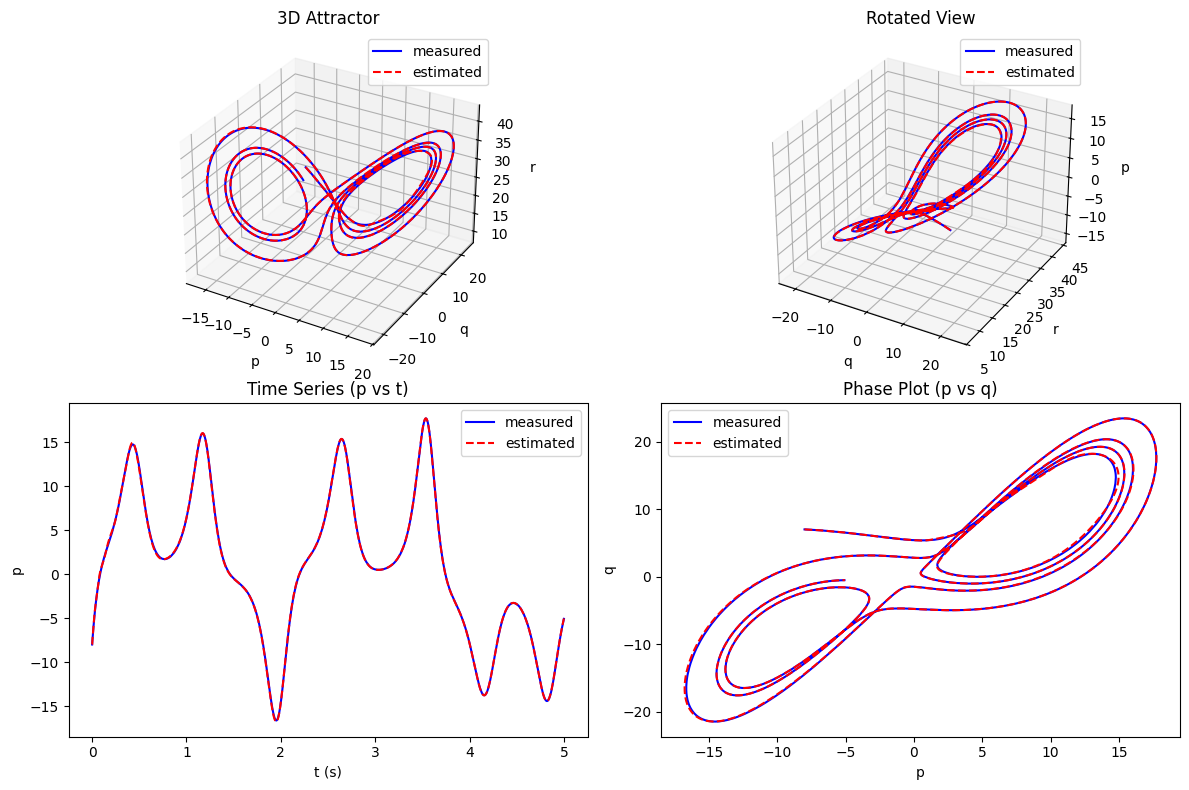

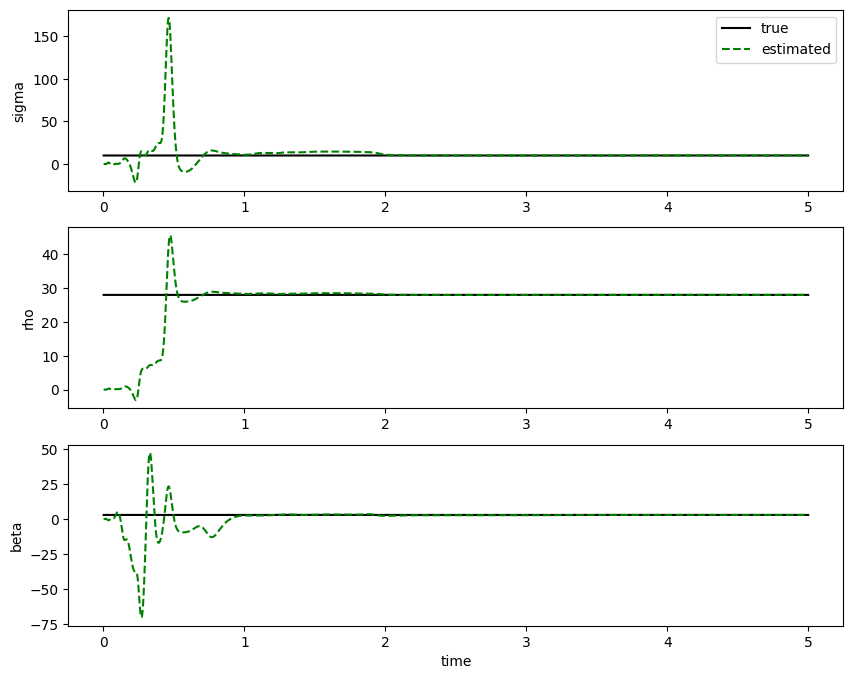

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# time horizon
tf = 5
dt = 0.001
t = np.arange(dt, tf + dt, dt)

# number of variables and coefficients
n = 3
r = 30

# noise
R = 1

# state initialization
x = np.array([-8, 7, 27], dtype=float)
xbar = x.copy()
y = x.copy()
thetabar = np.zeros(r)

# true parameters
sigma = 10
rho = 28
beta = 3

# arrays for plotting
xArray = []
xbarArray = []
yArray = []
thetabarArray = []

# estimator initialization
lambdav = 0.995
lambdat = 0.999
Rx = np.eye(n)
Rt = np.eye(n)
Px = 0.1 * np.eye(n)
Pt = 0.1 * np.eye(r)
Gamma = np.zeros((n, r))

# simulation
for i in range(int(tf/dt)):

    xArray.append(x.copy())
    xbarArray.append(xbar.copy())
    yArray.append(y.copy())
    thetabarArray.append(thetabar.copy())

    # Lorenz system
    dx = np.array([
        10*(x[1]-x[0]),
        x[0]*(28-x[2]) - x[1],
        x[0]*x[1] - 3*x[2]
    ])

    x = x + dt * dx
    y = x + dt * (R**2) * np.random.randn(n)

    # Phi matrix
    Phi = np.zeros((3, 30))

    Phi[0,:10] = [
        1, y[0], y[1], y[2],
        y[0]**2, y[1]**2, y[2]**2,
        y[0]*y[1], y[0]*y[2], y[1]*y[2]
    ]

    Phi[1,10:20] = Phi[0,:10]
    Phi[2,20:30] = Phi[0,:10]

    # Estimator
    Kx = Px @ np.linalg.inv(Px + Rx)
    Kt = Pt @ Gamma.T @ np.linalg.inv(Gamma @ Pt @ Gamma.T + Rt)

    Gamma = (np.eye(n) - Kx) @ Gamma

    xbar = xbar + (Kx + Gamma @ Kt) @ (y - xbar)
    thetabar = thetabar - Kt @ (y - xbar)

    xbar = xbar + Phi @ thetabar

    Px = (1/lambdav) * (np.eye(n) - Kx) @ Px
    Pt = (1/lambdat) * (np.eye(r) - Kt @ Gamma) @ Pt

    Gamma = Gamma - Phi

# convert arrays
xArray = np.array(xArray).T
xbarArray = np.array(xbarArray).T
yArray = np.array(yArray).T
thetabarArray = np.array(thetabarArray).T



# Figure with 4 subplots
fig = plt.figure(figsize=(12, 8))

# 3D Lorentz Attractor
ax1 = fig.add_subplot(221, projection='3d')
ax1.plot(yArray[0], yArray[1], yArray[2], 'b')
ax1.plot(xbarArray[0], xbarArray[1], xbarArray[2], 'r--')
ax1.set_title("3D Attractor")
ax1.set_xlabel("p")
ax1.set_ylabel("q")
ax1.set_zlabel("r")
ax1.legend(["measured", "estimated"])


# Rotated 3D view
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot(yArray[1], yArray[2], yArray[0], 'b')
ax2.plot(xbarArray[1], xbarArray[2], xbarArray[0], 'r--')
ax2.set_title("Rotated View")
ax2.set_xlabel("q")
ax2.set_ylabel("r")
ax2.set_zlabel("p")
ax2.legend(["measured", "estimated"])


# Time series plot
ax3 = fig.add_subplot(223)
ax3.plot(t, yArray[0], 'b')
ax3.plot(t, xbarArray[0], 'r--')
ax3.set_title("Time Series (p vs t)")
ax3.set_xlabel("t (s)")
ax3.set_ylabel("p")
ax3.legend(["measured", "estimated"])


# 2D phase plot
ax4 = fig.add_subplot(224)
ax4.plot(yArray[0], yArray[1], 'b')
ax4.plot(xbarArray[0], xbarArray[1], 'r--')
ax4.set_title("Phase Plot (p vs q)")
ax4.set_xlabel("p")
ax4.set_ylabel("q")
ax4.legend(["measured", "estimated"])

plt.tight_layout()


# parameter plots
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t, sigma*np.ones_like(t), 'k')
plt.plot(t, -thetabarArray[1]/dt, 'g--')
plt.ylabel("sigma")
plt.legend(["true","estimated"])

plt.subplot(3,1,2)
plt.plot(t, rho*np.ones_like(t), 'k')
plt.plot(t, thetabarArray[11]/dt, 'g--')
plt.ylabel("rho")

plt.subplot(3,1,3)
plt.plot(t, beta*np.ones_like(t), 'k')
plt.plot(t, -thetabarArray[23]/dt, 'g--')
plt.ylabel("beta")
plt.xlabel("time")

plt.show()
